### Import Packages

In [2]:
import os
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from diffusers import UNet1DModel
from diffusers.schedulers.scheduling_ddim import DDIMScheduler
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

print("PyTorch version: ", torch.__version__)
print("Number of GPUs available: ", torch.cuda.device_count())

PyTorch version:  2.8.0+cu128
Number of GPUs available:  1


### Data Preprocessing

In [3]:
wind_cols = ['uSq','e_uSq','n_uSq','Z2','Z3','Z4']
scaled_wind_cols = ['scaled_' + col for col in wind_cols]

# Load datasets
df = pd.read_csv('WLIS_data.csv')
df = df.rename(columns={'WSPD':'u', 'Fetch':'Z3'})
df['TmStamp'] = pd.to_datetime(df['TmStamp'], format='mixed')
df.set_index('TmStamp', inplace=True)

# Add squared terms (uSq)
df['uSq'] = df['u']**2

# Add east and north components (e_uSq, n_uSq)
alpha = -13
df['rad'] = np.pi/180 * ((alpha + 630 - df['WDIR']) % 360)
df['e_uSq'] = df['uSq'] * np.cos(df['rad'])
df['n_uSq'] = df['uSq'] * np.sin(df['rad'])

# Add interaction terms (Z2, Z4)
df['Z2'] = np.sqrt(df['Z3']) * df['u']
df['Z4'] = (df['Z3']**1.5) / df['u']

# Train-Test split
# df_test: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
df_train = df[(df.index < split1) | (df.index > split2)]
df_test = df[(df.index > split1) & (df.index < split2)]

# Data normalization
scaled_wave, scaled_wind = MinMaxScaler(), MinMaxScaler()
df_train, df_test = df_train.copy(), df_test.copy()
df_train.loc[:, 'scaled_H'] = scaled_wave.fit_transform(df_train[['H']])
df_test.loc[:, 'scaled_H'] = scaled_wave.transform(df_test[['H']])
df_train.loc[:, scaled_wind_cols] = scaled_wind.fit_transform(df_train[wind_cols])
df_test.loc[:, scaled_wind_cols] = scaled_wind.transform(df_test[wind_cols])

### Data Preparation: Train-Test-Validation Split

In [4]:
step, output = 24, 24
features = ['scaled_H'] + scaled_wind_cols

def create_sequences(df, step, output):
    X, y = [], []
    periods = step + output
    for i in range(len(df) - periods + 1):
        window = df.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        ## Case 1 & 2 & 3 & 4
        X_seq = window.iloc[:step, :].values
        ## Case 5
        # X_seq = window.values.copy()
        # X_seq[step:, 0] = -1
        y_seq = window.iloc[step:, 0].values
        X.append(X_seq)
        y.append(y_seq)
    return np.array(X), np.array(y)

# Validation set: [2008-11-01 00:00:00 ~ 2009-10-31 23:00:00]
split3 = pd.to_datetime('2009-10-31 23:59:00')
df_val = df_train[(df_train.index > split2) & (df_train.index < split3)]
df_train = df_train[(df_train.index < split1) | (df_train.index > split3)]

X_train, y_train = create_sequences(df_train[features], step, output)
X_val, y_val = create_sequences(df_val[features], step, output)
X_test, y_test = create_sequences(df_test[features], step, output)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(105655, 24, 7) (105655, 24)
(8713, 24, 7) (8713, 24)
(8737, 24, 7) (8737, 24)


### Model Selection and Implementation

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)                                   # [max_len, d_model]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))  # [d_model/2]
        pe[:, 0::2] = torch.sin(position * div_term)  # even
        pe[:, 1::2] = torch.cos(position * div_term)  # odd
        pe = pe.unsqueeze(0)                          # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]          # [B, seq_len, d_model]

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, d_model, num_heads=4):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, d_model))
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)

    def forward(self, x):                             # [B, seq_len, d_model]
        query = self.query.expand(x.size(0), -1, -1)  # [B, 1, d_model]
        out, _ = self.attn(query, x, x)               # [B, 1, d_model]
        return out.squeeze(1)                         # [B, d_model]

class ConditionEncoder(nn.Module):
    def __init__(self, input_dim=X_train.shape[2], seq_len=X_train.shape[1], d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=seq_len)
        te_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.trans_encoder = nn.TransformerEncoder(te_layer, num_layers=num_layers)
        self.attn_pool = MultiHeadAttentionPooling(d_model, num_heads=4)
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Linear(d_model//2, output)
        )
    
    def forward(self, x):          # [B, seq_len, input_dim]
        x = self.input_proj(x)     # [B, seq_len, d_model]
        x = self.pos_encoder(x)    # Positional encoding
        x = self.trans_encoder(x)  # Transformer encoding
        x = self.attn_pool(x)      # [B, d_model]
        x = self.output_proj(x)    # [B, output]
        x = x.unsqueeze(1)         # [B, 1, output]
        return x

class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.condition_encoder = ConditionEncoder()
        self.unet = UNet1DModel(
            sample_size=output,
            in_channels=2,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(64, 128),
            down_block_types=('DownBlock1D',) * 2,
            up_block_types=('UpBlock1D',) * 2,
        )

    def forward(self, x, t, cond_input):
        cond = self.condition_encoder(cond_input)
        x_cat = torch.cat([x, cond], dim=1)  # [B, 2, output]
        return self.unet(x_cat, t).sample    # [B, 1, output]

class WaveDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'condition': torch.tensor(self.X[idx], dtype=torch.float32),
            'target': torch.tensor(self.y[idx], dtype=torch.float32)
        }

class DiffusionLightningModule(pl.LightningModule):
    def __init__(self, lr=2e-4):
        super().__init__()
        self.model = ConditionalUNet()
        self.noise_scheduler = DDIMScheduler(num_train_timesteps=1000)
        self.noise_scheduler.set_timesteps(100)
        self.lr = lr

    def training_step(self, batch, batch_idx):
        x0 = batch['target'].unsqueeze(1)
        cond = batch['condition']
        noise = torch.randn_like(x0)
        t = torch.randint(0, 1000, (1,), device=self.device).long().item()
        timesteps = torch.full((x0.shape[0],), t, device=self.device).long()
        x_noisy = self.noise_scheduler.add_noise(x0, noise, timesteps)
        pred_noise = self.model(x_noisy, timesteps, cond)
        x0_pred = self.noise_scheduler.step(pred_noise, t, x_noisy).pred_original_sample
        loss1 = F.mse_loss(pred_noise, noise)
        loss2 = F.l1_loss(x0_pred, x0)
        loss = loss1 + 0.1 * loss2
        self.log('train_loss', loss)
        self.log('train_noise_loss', loss1)
        self.log('train_recon_loss', loss2)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x0 = batch['target'].unsqueeze(1)
        cond = batch['condition']
        noise = torch.randn_like(x0)
        t = torch.randint(0, 1000, (1,), device=self.device).long().item()
        timesteps = torch.full((x0.shape[0],), t, device=self.device).long()
        x_noisy = self.noise_scheduler.add_noise(x0, noise, timesteps)
        pred_noise = self.model(x_noisy, timesteps, cond)
        x0_pred = self.noise_scheduler.step(pred_noise, t, x_noisy).pred_original_sample
        loss1 = F.mse_loss(pred_noise, noise)
        loss2 = F.l1_loss(x0_pred, x0)
        loss = loss1 + 0.1 * loss2
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_noise_loss', loss1, prog_bar=False)
        self.log('val_recon_loss', loss2, prog_bar=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

In [ ]:
dirpath = '/home/zhr19002/ML_Projects/DL_Diffusion_Forecast/checkpoints/'

train_ds = WaveDataset(X_train, y_train)
val_ds = WaveDataset(X_val, y_val)
train_loader = DataLoader(train_ds, batch_size=32, num_workers=3, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=3)

model = DiffusionLightningModule()
ckpt = ModelCheckpoint(monitor='val_loss', filename='best_model', save_top_k=1, save_last=False, mode='min', dirpath=dirpath)
es = EarlyStopping(monitor='val_loss', patience=10, mode='min')
trainer = pl.Trainer(max_epochs=50, accelerator='auto', callbacks=[ckpt, es], log_every_n_steps=10)
trainer.fit(model, train_loader, val_loader)

### Model Evaluation

In [7]:
model = DiffusionLightningModule.load_from_checkpoint(dirpath + 'best_model.ckpt')
model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.noise_scheduler.set_timesteps(num_inference_steps=100)

X = torch.tensor(X_test, dtype=torch.float32, device=model.device)
x = torch.randn((X.shape[0], 1, output), device=model.device)
with torch.no_grad():
    for t in model.noise_scheduler.timesteps:
        x = model.noise_scheduler.step(model.model(x, t, X), t, x).prev_sample

# Test error
y_pred3 = x.squeeze(1).cpu().numpy()
y_pred3_raw = scaled_wave.inverse_transform(y_pred3)
y_true3 = scaled_wave.inverse_transform(y_test)
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_true3, y_pred3_raw)):.3f}')
rmse_array3 = np.sqrt(mean_squared_error(y_true3, y_pred3_raw, multioutput='raw_values'))
print('Test RMSE per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_array3]))

Test RMSE: 4.803
Test RMSE per output: 4.451, 4.201, 5.436, 4.477, 4.751, 4.952, 4.825, 5.023, 4.876, 4.953, 4.916, 5.017, 4.645, 4.918, 4.826, 4.939, 5.049, 5.240, 5.124, 5.096, 4.787, 4.700, 3.828, 3.895


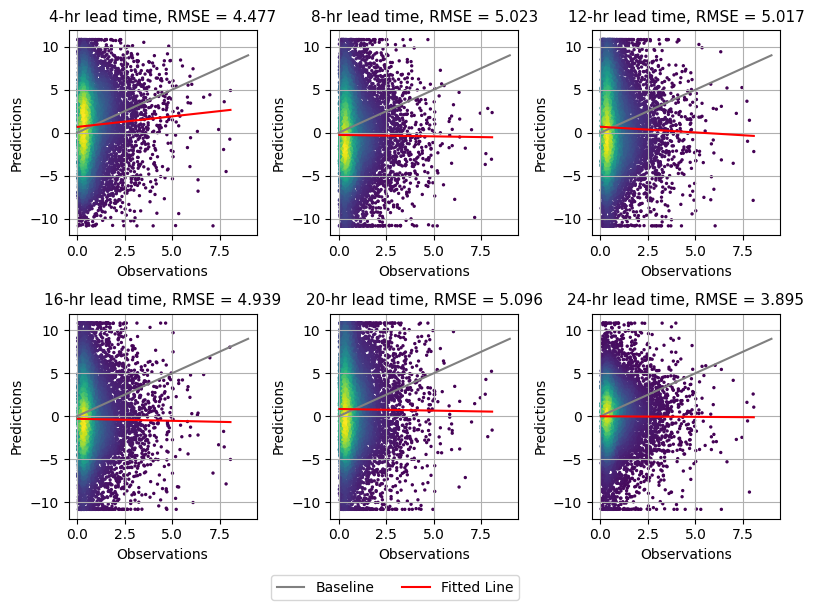

In [8]:
def pred_vs_obs(y_true, y_pred, rmse_array):
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()
    baseline, = plt.plot([], [], color='grey', label='Baseline')
    fit_line, = plt.plot([], [], color='r', label='Fitted Line')

    for i in range(3, 24, 4):
        ax = axes[i//4]
        yt, yp = y_true[:,i], y_pred[:,i].flatten()

        ax.plot([0, 9], [0, 9], color='grey')
        ax.plot(np.unique(yt), np.poly1d(np.polyfit(yt, yp, 1))(np.unique(yt)), color='r')
        kernel = stats.gaussian_kde(np.vstack([yt, yp]))(np.vstack([yt, yp]))
        ax.scatter(yt, yp, c=kernel, s=2, cmap='viridis')

        ax.set_title(f'{i+1}-hr lead time, RMSE = {rmse_array[i]:.3f}', fontsize=11)
        ax.set(xlabel='Observations', ylabel='Predictions')
        ax.grid(True)

    fig.legend(handles=[baseline, fit_line], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

pred_vs_obs(y_true3, y_pred3_raw, rmse_array3)

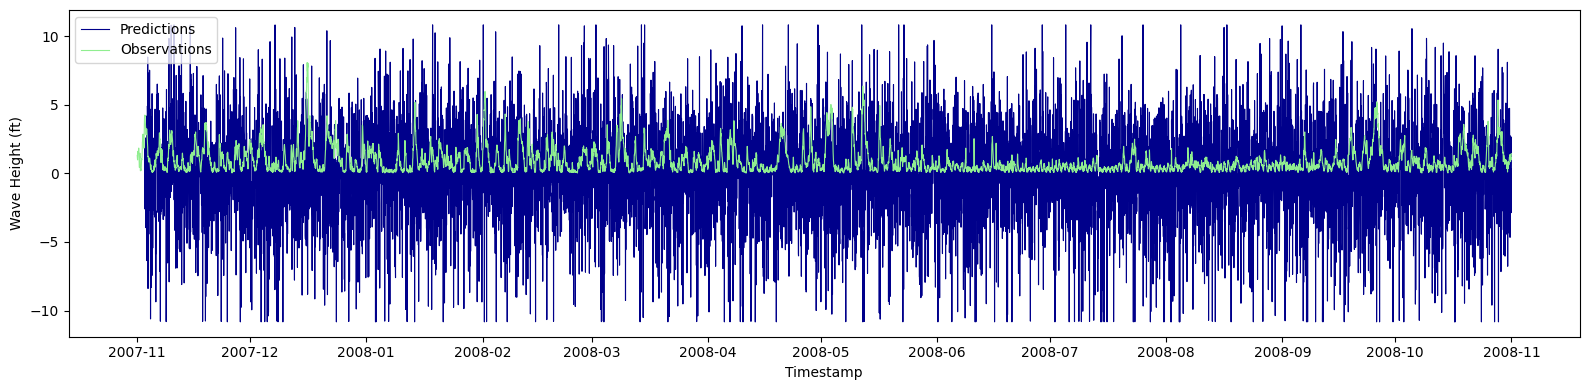

In [9]:
idx = 23
start = step + idx
end = len(df_test) - (output - idx - 1)

plt.figure(figsize=(16, 4))
plt.plot(df_test.index[start:end], y_pred3_raw[:, idx], linewidth=0.8, color='darkblue', label='Predictions')
plt.plot(df_test.index, df_test['H'], linewidth=0.8, color='lightgreen', label='Observations')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Timestamp')
plt.ylabel('Wave Height (ft)')
plt.legend()

plt.tight_layout()
plt.show()